### Import libraries

In [4]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import jax.numpy as jnp

digits = load_digits()
splits = train_test_split(digits.images, random_state = 0)

train_image, test_image = map(jnp.asarray, splits)

print(f"{train_image.shape=}")
print(f"{test_image.shape=}")

train_image.shape=(1347, 8, 8)
test_image.shape=(450, 8, 8)


### Creating the VAE

In [70]:
from flax import nnx

class Encoder(nnx.Module):
    def __init__(self, din: int, dhidden: int, dout: int, *, rngs = nnx.Rngs):
        self.rngs = rngs
        self.linear = nnx.Linear(din, dhidden, rngs = rngs)
        self.linear_mean = nnx.Linear(dhidden, dout, rngs = rngs)
        self.linear_std = nnx.Linear(dhidden, dout, rngs = rngs)
    
    def __call__(self, x: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x = self.linear(x)
        x = jax.nn.relu(x)

        mean = self.linear_mean(x)
        std = self.linear_std(x)

        key = self.rngs.noise()
        z = mean + std * jax.random.normal(key, mean.shape)
        return z, mean, std

class Decoder(nnx.Module):
    def __init__(self, din: int, dhidden: int, dout: int, *, rngs = nnx.Rngs):
        self.linear_1 = nnx.Linear(din, dhidden, rngs = rngs)
        self.linear_2 = nnx.Linear(dhidden, dout, rngs = rngs)
    
    def __call__(self, x: jax.Array) -> jax.Array:
        z = self.linear_1(x)
        z = jax.nn.relu(z)
        logits = self.linear_2(z)
        return logits

In [71]:
class VAE(nnx.Module):
    def __init__(self, image_shape: tuple[int, int], hidden_shape: int, latent_shape: int, *, rngs = nnx.Rngs):
        self.image_shape = image_shape
        self.latent_shape = latent_shape
        image_size = image_shape[0] * image_shape[1]
        self.encoder = Encoder(image_size, hidden_shape, latent_shape, rngs = rngs)
        self.decoder = Decoder(latent_shape, hidden_shape, image_size, rngs = rngs)

    def __call__(self, x: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x = jax.vmap(jax.numpy.ravel)(x)
        z, mean, std = self.encoder(x)
        logits = self.decoder(z)
        logits = jnp.reshape(logits, (-1, *self.image_shape))
        return logits, mean, std

### Training the model

In [87]:
import optax

def vae_loss(model: VAE, x: jax.Array):
    logits, mean, std = model(x)
    kl_loss = jnp.mean(0.5 * jnp.mean(-jnp.log(std ** 2) - 1.0 + std ** 2 + mean ** 2, axis = -1))
    reconstruction_loss = jnp.mean(optax.sigmoid_binary_cross_entropy(logits, x))

    # kl_loss = jnp.mean(0.5 * jnp.mean(
    #   -jnp.log(std ** 2) - 1.0 + std ** 2 + mean ** 2, axis=-1))
    # reconstruction_loss = jnp.mean(optax.sigmoid_binary_cross_entropy(logits, x))
    # jax.debug.print("kl loss: {}", kl_loss)
    # jax.debug.print("reconstruction loss: {}", reconstruction_loss)
    return reconstruction_loss + 0.1 * kl_loss

In [88]:
images_norm = (digits.images / 16)
# print(images_norm[0])
splits = train_test_split(images_norm, random_state=0)
train_image, test_image = map(jnp.asarray, splits)

model = VAE(image_shape = (8, 8), hidden_shape = 32, latent_shape = 8, rngs = nnx.Rngs(0, noise = 1))
optimizer = nnx.ModelAndOptimizer(model, optax.adam(1e-3))

@nnx.jit
def train_step(model: VAE, optimizer: nnx.Optimizer, x: jax.Array):
    loss, grads = nnx.value_and_grad(vae_loss)(model, x)
    optimizer.update(grads)
    return loss

for epoch in range(5001):
    loss = train_step(model, optimizer, train_image)
    if epoch % 500 == 0:
        print(f"epoch: {epoch}, loss: {loss}")



epoch: 0, loss: 0.8803960084915161
epoch: 500, loss: 0.4387996792793274
epoch: 1000, loss: 0.4091895818710327
epoch: 1500, loss: 0.39857643842697144
epoch: 2000, loss: 0.39352309703826904
epoch: 2500, loss: 0.3901413679122925
epoch: 3000, loss: 0.38616639375686646
epoch: 3500, loss: 0.383929044008255
epoch: 4000, loss: 0.38260117173194885
epoch: 4500, loss: 0.380702406167984
epoch: 5000, loss: 0.3790387511253357


### Visualization

In [84]:
logits, mean, std = model(test_image)
pred = nnx.sigmoid(logits)
pred.shape

(450, 8, 8)

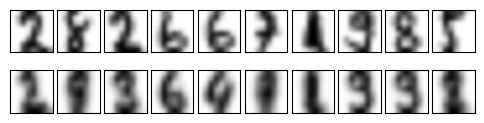

In [85]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 10, figsize = (6, 1.5), subplot_kw = {'xticks':[], 'yticks':[]}, gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i in range(10):
    ax[0, i].imshow(test_image[i], cmap='binary', interpolation='gaussian')
    ax[1, i].imshow(pred[i], cmap='binary', interpolation='gaussian')

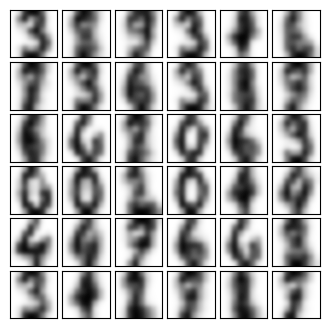

In [86]:
import numpy as np

# generate new images by sampling the latent space
z = np.random.normal(scale=1.5, size=(36, model.latent_shape))
logits = model.decoder(z).reshape(-1, 8, 8)
images_gen = nnx.sigmoid(logits)

fig, ax = plt.subplots(6, 6, figsize=(4, 4),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(36):
  ax.flat[i].imshow(images_gen[i], cmap='binary', interpolation='gaussian')